## Oövervakad inlärning 

### Vad är det?
- Inga labels (inga rätta svar)
- Modellen hittar mönster själv

**Varför är klustring användbart?**

1. Skapa labels:
 
Om du inte har labels: använd klustring → skapa grupper , använd dessa som fake labels ,träna sedan en supervised model

2. Analys av data : 

förstå struktur  ,hitta mönster

### Viktig idé
- Clustering kan skapa labels
- → kan användas senare i supervised learning

### När funkar det?
- Bra: tydliga grupper i data
- Dåligt: blandad/otydlig data

### **_K-means Algorithm:_**

Hur fungerar K-means?

- välj antal kluster (K)
- slumpa startpunkter
- koppla varje punkt till närmaste center
- räkna nytt center (medelvärde)
- upprepa tills stabilt

Största problemet!  Hur vet man K?  **K = antal kluster**

1. Metod 1: Elbow method

plottar error vs K
välj där kurvan "böjer sig"

2. Metod 2: Silhouette score

vi kan ofta **inte visualisera kluster** (för många dimensioner)

Lösning: använd ett mått → **Silhouette score**

 Vad mäter Silhouette score?

Hur bra en punkt passar i sitt kluster . Den jämför:

1. hur nära punkten är sitt eget kluster
2. hur långt den är från andra kluster

mäter: hur täta klustren är . hur separerade de är värde:(silhouette score is a measure of cluster tightness)

- nära 1 → bra
- nära 0 → överlappar
- nära -1 → dåligt

Viktig detalj – standardisering : klustring bygger på avstånd .Olika skalor → fel resultat.

**Begränsning med K-means:** måste välja K , känslig för startpunkt , funkar dåligt om kluster inte är “runda".klarar inte brus (noise)

### **_DBSCAN_**

En klustringsalgoritm som inte kräver K , hittar kluster baserat på täthet (density) ,istället för avstånd till center ,tittar den på hur nära punkter ligger varandra

Hur DBSCAN fungerar? 

Den använder : 

- **eps** → hur nära punkter ska vara
- **min_samples** → min antal punkter för att bilda ett kluster

om tillräckligt många punkter är nära → kluster

DBSCAN kan säga:

"den här punkten hör inte till något kluster” dessa kallas: outliers ,anomalies.

Varför outliers är viktiga?

Detta är en av de största användningarna i verkligheten .

Exempel:

**Kreditkort**
normal beteende → kluster
konstig transaktion → outlier

→ kan vara bedrägeri

**Säkerhetssystem**
normal aktivitet → kluster
konstigt beteende → outlier

→ något är fel

**Begränsningar med DBSCAN:** svårt att välja parametrar , fungerar sämre om datan har olika täthet.

## Bildbehandling med K-means:

### Grundidé
- En bild = många pixlar
- Varje pixel = färg (RGB)

### Problem
- Bilder innehåller många olika färger
- → tar mycket plats (mycket data)

### Lösning: K-means
- Grupperar liknande färger (kluster)
- Varje kluster får ett medelvärde (en färg)

### Process
1. Välj antal färger (K)
2. Kör K-means på pixelvärden
3. Ersätt varje pixel med sitt klusters färg

### Resultat
- Färre färger i bilden
- Mindre datastorlek
- Bilden ser nästan likadan ut

### Viktig detalj
- Färger blir ibland “gråare”
- (pga medelvärde i kluster)

### Segmentering
- Klustring kan dela upp bilden i delar
- T.ex:
  - objekt vs bakgrund

### Mask
- Välj ett kluster
- isolera en del av bilden

### Användning
- Bildkompression
- Bildanalys
- AI / computer vision

### Viktig insikt
- Samma idé som all klustring:
  → gruppera liknande saker

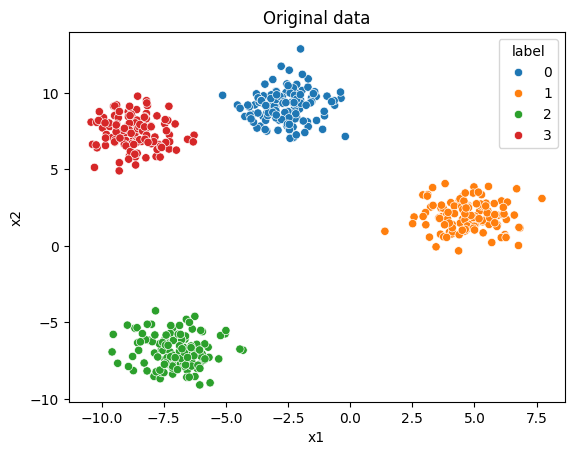

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#plt.style.use("seaborn-white")

X, y = make_blobs(500, centers=4, random_state=42, cluster_std=1) # make_blobs :skapar syntetisk data (kluster)

# , columns = ["x1", "x2", "label"])
df = pd.DataFrame([X[:, 0], X[:, 1], y]).T

df.columns = ["x1", "x2", "label"]
df["label"] = df.label.astype(int)

sns.scatterplot(data=df, x="x1", y="x2", hue="label", palette="tab10")
plt.title("Original data");

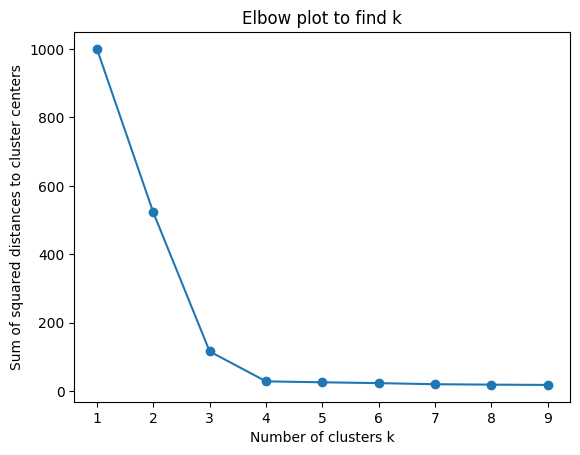

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

clusters = range(1, 10)
sum_squared_distances = [KMeans(k).fit(scaled_X).inertia_ for k in clusters]

fig, ax = plt.figure(), plt.axes()
ax.plot(clusters, sum_squared_distances, '-o')
ax.set(title="Elbow plot to find k", xlabel="Number of clusters k",
       ylabel="Sum of squared distances to cluster centers");

Vad är inertia_?

det är: sum of squared distances (WCSS) ,betyder: hur långt punkter är från sina kluster-center

✔️ lägre = bättre kluster

**summan av kvadrerade avstånd mellan varje punkt och dess kluster-center**